[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NU-MSE-LECTURES/465_Computational_Microscopy_2026/blob/dev/Week_01/assignments/assignment_01_setup.ipynb)

# Assignment 1: Environment Setup and Python Basics
**Due Date:** January 16, 2026

## Instructions
1.  Complete the tasks in the cells below.
2.  Ensure all code runs without errors.
3.  Submit your completed notebook via Canvas (or GitHub if instructed).

In [63]:
# Colab setup
try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab. Installing requirements...")
    !pip install hyperspy ase py4DSTEM
    !git clone https://github.com/NU-MSE-LECTURES/465_Computational_Microscopy_2026.git
    print("Setup complete.")
except ImportError:
    IN_COLAB = False
    print("Not running in Google Colab.")

Not running in Google Colab.


## Task 1: Environment Verification

Write a Python script to:
1.  Import `sys`, `numpy`, and `matplotlib`.
2.  Print the Python version.
3.  Print the versions of `numpy` and `matplotlib`.

In [64]:
# Your code here
import sys
import numpy as np
import matplotlib

print(f"Python version: {sys.version}")
print(f"NumPy version: {np.__version__}")
print(f"Matplotlib version: {matplotlib.__version__}")

Python version: 3.11.14 | packaged by conda-forge | (main, Oct 22 2025, 22:56:31) [Clang 19.1.7 ]
NumPy version: 1.26.4
Matplotlib version: 3.10.8


## Task 2: Automate Project Structure

Write a Python script using `os` or `pathlib` to programmatically create the following directory structure inside a folder named `assignment_01_output`:
```
assignment_01_output/
├── data/
│   ├── raw/
│   └── processed/
├── figures/
└── src/
```

In [65]:
# Your code here
import os

base_dir = "assignment_01_output"
subdirs = [
    "data/raw",
    "data/processed",
    "figures",
    "src"
]

for subdir in subdirs:
    path = os.path.join(base_dir, subdir)
    os.makedirs(path, exist_ok=True)
    print(f"Created directory: {path}")

Created directory: assignment_01_output/data/raw
Created directory: assignment_01_output/data/processed
Created directory: assignment_01_output/figures
Created directory: assignment_01_output/src


## Task 3: Ensure Reproducibility

Demonstrate reproducibility by:
1.  Setting a random seed using `numpy.random.seed()`.
2.  Generating an array of 5 random numbers.
3.  Printing the array.
4.  Run the cell multiple times to verify that the numbers remain the same.

In [66]:
# Your code here
import numpy as np

# Set the seed
np.random.seed(42)

# Generate random numbers
random_numbers = np.random.rand(5)
print(f"Random numbers: {random_numbers}")

Random numbers: [0.37454012 0.95071431 0.73199394 0.59865848 0.15601864]


## 1. Environment Documentation

In [67]:
import sys
import platform

print("Python version:", sys.version)
print("Operating system:", platform.system(), platform.release())


Python version: 3.11.14 | packaged by conda-forge | (main, Oct 22 2025, 22:56:31) [Clang 19.1.7 ]
Operating system: Darwin 22.3.0


In [68]:
# Import necessary modules
import numpy
import scipy
import matplotlib
import hyperspy
import py4DSTEM

# Versions of key packages
print("NumPy version:", numpy.__version__)
print("SciPy version:", scipy.__version__)
print("Matplotlib version:", matplotlib.__version__)
print("HyperSpy version:", hyperspy.__version__)
print("py4DSTEM version:", py4DSTEM.__version__)



NumPy version: 1.26.4
SciPy version: 1.10.1
Matplotlib version: 3.10.8
HyperSpy version: 2.3.0
py4DSTEM version: 0.14.16


## 2. EM Data Analysis

### A. Data Display

<Signal2D, title: , dimensions: (|503, 503)>
Shape:<Axes manager, axes: (|503, 503)>
            Name |   size |  index |  offset |   scale |  units 
================ | ====== | ====== | ======= | ======= | ====== 
---------------- | ------ | ------ | ------- | ------- | ------ 
           width |    503 |      0 |      -0 |       1 | <undefined> 
          height |    503 |      0 |      -0 |       1 | <undefined> 


The module `rsciio.utils.rgb_tools` has been renamed to `rsciio.utils.rgb` and it will be removed in version 1.0.
The module `rsciio.utils.rgb_tools` has been renamed to `rsciio.utils.rgb` and it will be removed in version 1.0.
The module `rsciio.utils.rgb_tools` has been renamed to `rsciio.utils.rgb` and it will be removed in version 1.0.


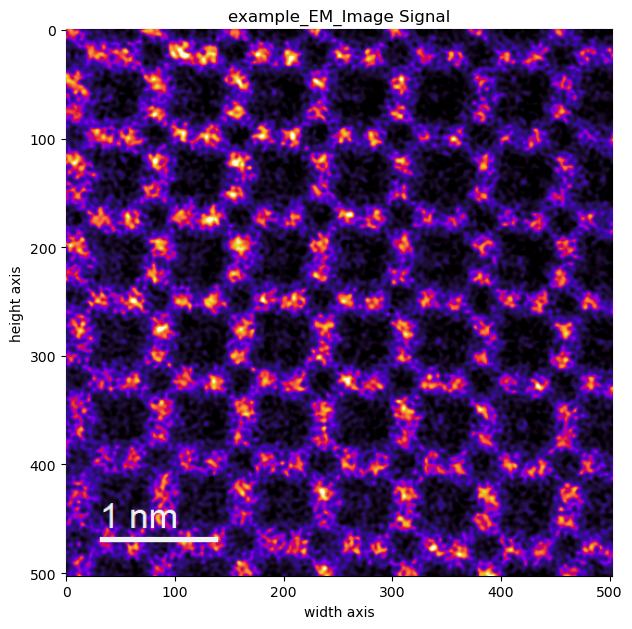

In [69]:
import hyperspy.api as hs
import matplotlib.pyplot as plt

# Load the TIFF image
img = hs.load("assignment_01_output/data/raw/example_EM_Image.tif")

print(img)
print(f"Shape:{img.axes_manager}")

img.plot(cmap="gray", scalebar=False)

### B. Greyscale Conversion

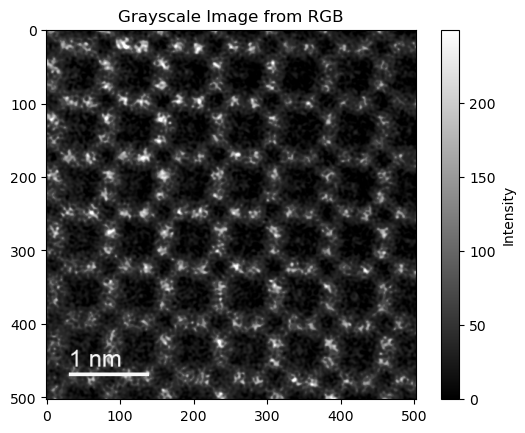

Mean intensity: 39.953
Standard deviation: 37.032
Range: (0.000, 249.461)


In [70]:
import numpy as np
import hyperspy.api as hs

img = hs.load("assignment_01_output/data/raw/example_EM_Image.tif")
data_rgb = img.data

# Convert structured array to 3D array (height, width, 3)
data_rgb = np.stack([data_rgb['R'], data_rgb['G'], data_rgb['B']], axis=-1)

# Convert to grayscale using standard luminance weights
data_gray = 0.2989 * data_rgb[..., 0] + 0.5870 * data_rgb[..., 1] + 0.1140 * data_rgb[..., 2]

# Display
plt.imshow(data_gray, cmap='gray', origin='upper')
plt.colorbar(label="Intensity")
plt.title("Grayscale Image from RGB")
plt.show()

mean_intensity = np.mean(data_gray)
std_intensity = np.std(data_gray)
intensity_range = (np.min(data_gray), np.max(data_gray))
print(f"Mean intensity: {mean_intensity:.3f}")
print(f"Standard deviation: {std_intensity:.3f}")
print(f"Range: ({intensity_range[0]:.3f}, {intensity_range[1]:.3f})")



### C. Intensity Histogram

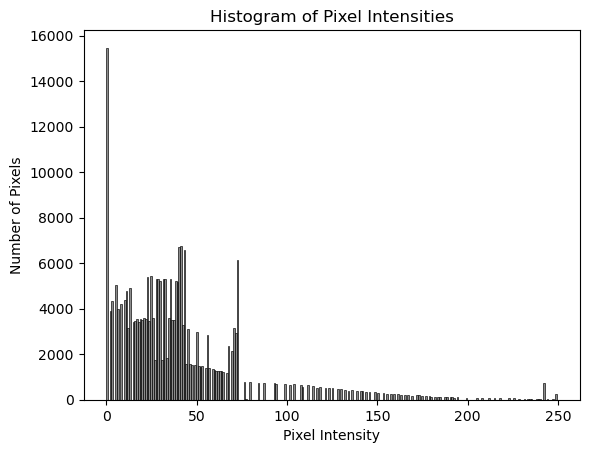

In [71]:
import matplotlib.pyplot as plt

plt.hist(data_gray.ravel(), bins=256, color="gray", edgecolor="black", linewidth=0.5, alpha=0.9)
plt.xlabel("Pixel Intensity")
plt.ylabel("Number of Pixels")
plt.title("Histogram of Pixel Intensities")
plt.show()


## Observations: 

The original EM image is a 2D pixel array in RGB format and the greyscale conversion represents the adjusted relative signal intensity of the image. From the structure of repeating octagonal rings (d~0.67nm) of bright spots surrounding dark regions, the dataset potentially features a crystal lattice of bright atoms with intense electron scattering and dark voids/low-density areas of weak response, where bonds between them occupy intermediate brightness. Analysis of mean, standard deviation, and intensity histogram shows a cluster of intensities between 0-75 on a scale of 0-250 and a significant peak near zero, consistent with the expected electron scattering pattern of a crystalline arrangement.